In [1]:
import numpy as np
import xarray as xr
import json

import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

import matplotlib.pyplot as plt
import matplotlib.animation as animation

from feature_retreiver import *
from utility import (
    calculate_f, calculate_T, calculate_analytical_m_star_N, calculate_analytical_m_star_Nb, 
    compute_tke_bl, calculate_rolling_average, calculate_mean_over_inertial_period,
    get_time_stamps_for_profiles, surface_value_z_grid, last_profile, compute_bl_rh18,
    compute_ekman_layer_thickness, compute_ekman_spiral, compute_u_star
)

In [2]:
training_set_name = "ePBL_paper_2283_corrected_dz1_nohf"
root_dir = "/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set"

In [4]:
with open(f"{root_dir}/case_dictionaries/{training_set_name}_training_set_cases.json", "r") as file:
    gotm_case_dict = json.load(file)

In [5]:
for case, specs in gotm_case_dict.items():
    if specs == {'lat': 90., 'tx': 0.01, 'heat_flux': 0., 'temp_grad': 0.01}:
        print(case) 
    else: pass

case_54


In [5]:
ds_1 = xr.open_dataset("/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/ePBL_paper_2283_corrected_f_u_star_grid_training_dataset/case_1/output.nc")
ds_2 = xr.open_dataset("/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/ePBL_paper_2283_corrected_f_u_star_grid_training_dataset/case_2/output.nc")

In [6]:
ds_2.zi[0,1].values - ds_2.zi[0,0].values

array([[0.00619888]], dtype=float32)

In [7]:
ds_1.G.values.shape

(484, 10001, 1, 1)

In [8]:
np.linspace(0, 20, 20*24).shape

(480,)

In [9]:
ds_2.G.values.shape

(493, 10001, 1, 1)

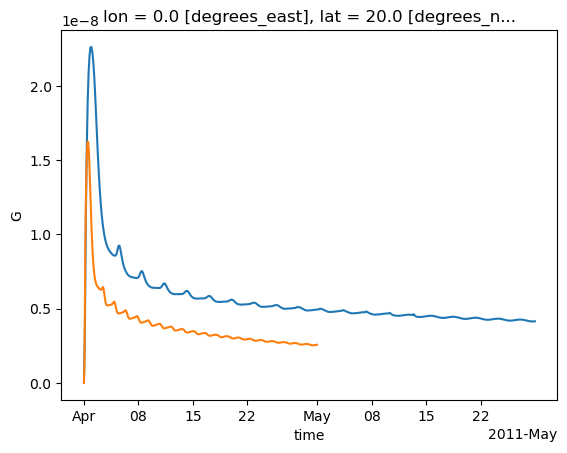

In [11]:
(-1*ds_1.G.sum(dim="zi")*(ds_1.zi[0,1].values - ds_1.zi[0,0].values)).plot()
(-1*ds_2.G.sum(dim="zi")*(ds_2.zi[0,1].values - ds_2.zi[0,0].values)).plot()

In [6]:
ds_1.NN.where(ds_1.tke > 1e-9).T.plot()

NameError: name 'ds_1' is not defined

In [7]:
# cases_subset = ["case_27", "case_37", "case_45", "case_46", "case_54", "case_90", "case_109", "case_117"]
cases_subset = ["case_1", "case_2", "case_3", "case_4", "case_5", "case_6", "case_7", "case_8", "case_9", "case_10"]
gotm_case_subset = {case: gotm_case_dict[case] for case in cases_subset}

In [10]:
feature_retreiver = FeatureRetreiver(
    training_set_dir=os.path.join(root_dir, f"{training_set_name}_training_dataset"),
    case_dict=gotm_case_dict,
    # case_dict=gotm_case_subset,
    # grid="f_u_star",
    # n_inertial_periods=20,
    # n_points_per_period=24
    grid="constant",
    dz=1.,
    dt=1800
)

In [8]:
np.arange(0,1.1,0.1)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [ ]:
target_vals = np.arange(0,1.1,0.1)

test = feature_retreiver.make_sigma_profile_dataset(
    variable="NN",
    sigma_grid=target_vals
)

In [14]:
M_dataset = feature_retreiver.make_M_dataset()

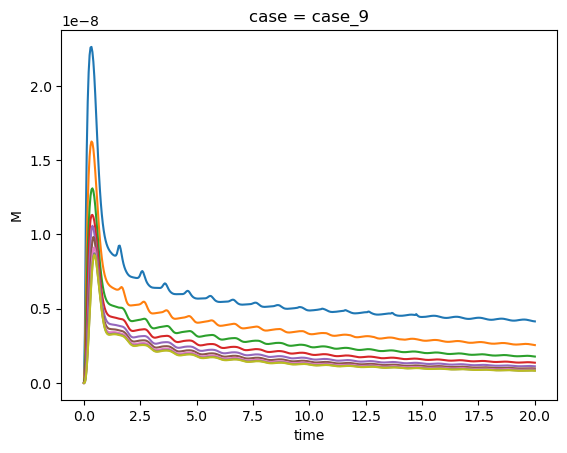

In [15]:
for i in range(len(gotm_case_subset)-1):
    M_dataset.isel(case=i).M.plot()

In [16]:
bl_dataset = feature_retreiver.make_dataset_from_processed_data(
    processing_method=compute_bl_rh18,
    processing_method_name="bl",
    variable="nuh",
    coordinates=["time"]
)

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/utility.py:94: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/utility.py:94: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/utility.py:94: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/utility.py:94: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/utility.py:94: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/utility.py:94: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1

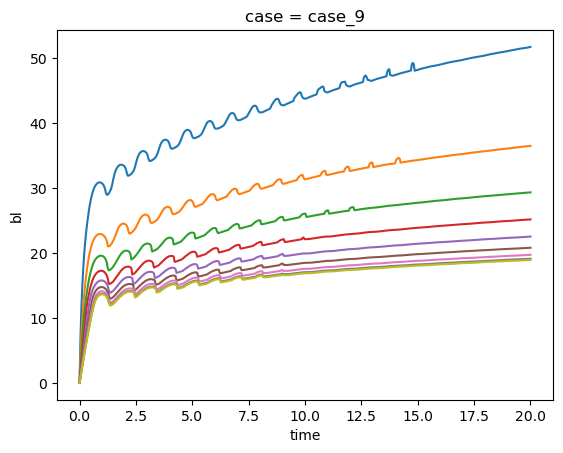

In [17]:
for i in range(len(gotm_case_subset)-1):
    bl_dataset.isel(case=i).bl.plot()

In [19]:
M_dataset = feature_retreiver.make_M_dataset()

u_dataset = feature_retreiver.make_dataset_from_processed_data(
    processing_method=surface_value_z_grid,
    processing_method_name="u_surf",
    variable="u",
    coordinates=["time"]
)

v_dataset = feature_retreiver.make_dataset_from_processed_data(
    processing_method=surface_value_z_grid,
    processing_method_name="v_surf",
    variable="v",
    coordinates=["time"]
)

rho_p_surf_dataset = feature_retreiver.make_dataset_from_processed_data(
    processing_method=surface_value_z_grid,
    processing_method_name="rho_p_surf",
    variable="rho_p",
    coordinates=["time"]
)

Ekin_dataset = feature_retreiver.make_dataset_from_raw_data(variable="Ekin", coordinates=["time"])

z_max = 10000
# z_max = 4000

Rig_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="Rig", z_max=z_max, index_above_bl=0)
u_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="u", z_max=z_max, index_above_bl=0)
v_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="v", z_max=z_max, index_above_bl=0)
SS_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="SS", z_max=z_max, index_above_bl=0)
NN_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="NN", z_max=z_max, index_above_bl=0)
rho_p_bl_dataset = feature_retreiver.make_var_at_bl_dataset(variable="rho_p", index_above_bl=0, z_max=z_max)

ekman_filtered_uv_dataset = feature_retreiver.make_ekman_filtered_uv_dataset()

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:245: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:245: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:245: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:245: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:245: RuntimeWarning: All-NaN slice encountered
  z_indices = np.nanmax(z_mask, axis=1)
/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feat

In [19]:
case_ind = 3
case_name = cases_subset[case_ind]
case_output = feature_retreiver.get_output(case_name)

bl_tke = compute_tke_bl(case_output).values

tke = case_output.tke.values
dzi = case_output.zi.values[0,1] - case_output.z.values[0,0]
dtke_dzi = (tke[:,:-2] - tke[:,2:]) / (2*dzi)
num = case_output.num[:,1:-1].values
dnumdtke_dzi2 = ((num * dtke_dzi)[:,:-2] - (num * dtke_dzi)[:,2:]) / (2*dzi)
zi = case_output.zi[0].values

dtke_dt = (tke[2:]-tke[:-2]) / 3600

latitude = gotm_case_subset[cases_subset[case_ind]]['lat']
tau = gotm_case_subset[cases_subset[case_ind]]['tx']
u_star = compute_u_star(tau=tau)
f = calculate_f(latitude=latitude)
dt = 1800

In [43]:
def shift_nans_numpy(a):
    mask = ~np.isnan(a)
    return np.concatenate([a[mask], a[~mask]])


def sample_from_bl_grid(
        output: xr.Dataset,
        variable: str,
        depths_to_sample_at: list,
        bl_threshold: float = 1e-9,
        bl_variable: str = "tke"
):
    masked_var = output[variable].where(output[bl_variable] > bl_threshold).T.values
    cleaned_var = masked_var[~np.isnan(masked_var).all(axis=1)]
    shifted_var = np.apply_along_axis(shift_nans_numpy, axis=0, arr=cleaned_var)
    var = np.where(np.isnan(shifted_var), 0, shifted_var)

    nz, _ = var.shape
    sigma_grid = np.linspace(1,0,nz)

    diff = np.abs(sigma_grid[:,np.newaxis]-depths_to_sample_at[np.newaxis,:])
    indices = np.argmin(diff, axis=0)

    return var, var[indices,:]

In [44]:
test_NN, test_NN_sampled = sample_from_bl_grid(
    output=case_output,
    variable="NN",
    depths_to_sample_at=np.arange(0,1.1,0.1)
)

In [45]:
test_NN_sampled.T.shape

(481, 11)

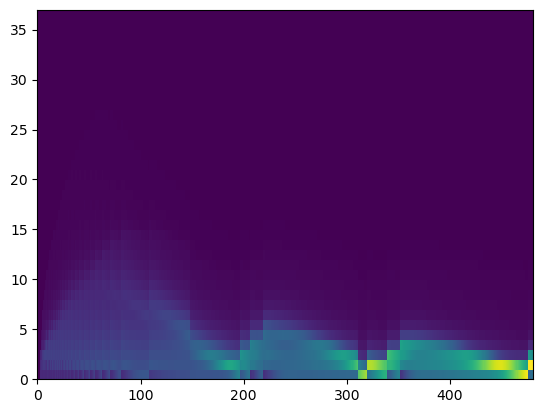

In [175]:
plt.pcolor(test_NN)

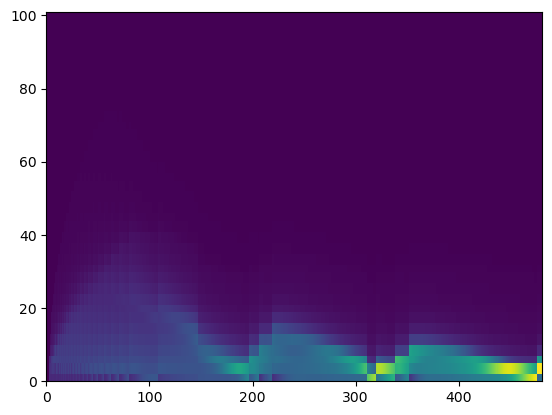

In [172]:
plt.pcolor(test_NN_sampled)

In [24]:
NN = case_output.NN.where(case_output.tke > 1e-9).T.values

In [113]:
SS = case_output.SS.where(case_output.tke > 1e-9).T.values

In [25]:
NN_cleaned = NN[~np.isnan(NN).all(axis=1)]

In [114]:
SS_cleaned = SS[~np.isnan(SS).all(axis=1)]

In [26]:


# Apply across the desired axis (e.g., rows)
result = np.apply_along_axis(shift_nans_numpy, axis=0, arr=NN_cleaned)

In [27]:
nz, nt = result.shape

In [28]:
sigma_grid = np.linspace(1,0,nz)

In [29]:
target_vals = np.arange(0,1.1,0.1)

In [30]:
target_vals

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [40]:
diff = np.abs(sigma_grid[:,np.newaxis]-target_vals[np.newaxis,:])

np.where(np.min(diff, axis=0)==diff)

(array([ 0,  2,  5,  7,  9, 11, 12, 14, 16, 18, 21, 23]),
 array([10,  9,  8,  7,  6,  5,  5,  4,  3,  2,  1,  0]))

In [41]:
vals, inverse, counts = np.unique(np.where(np.min(diff, axis=0)==diff)[1], return_inverse=True, return_counts=True)

repeated_indices = np.where(counts[inverse] > 1)[0]
print(repeated_indices)

[5 6]


In [42]:
np.where(np.min(diff, axis=0)==diff)[0][repeated_indices]

array([11, 12])

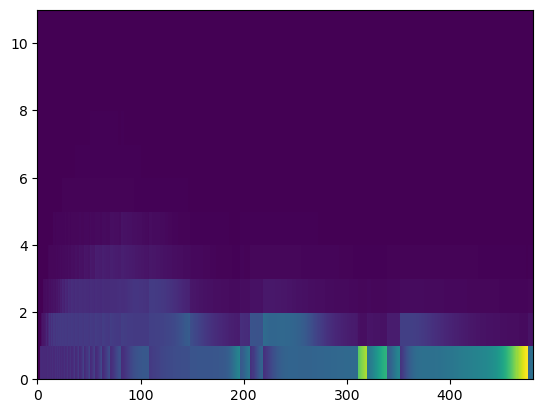

In [112]:
plt.pcolor(np.where(np.isnan(result), 0, result)[np.where(np.min(diff, axis=0)==diff)[0],:])

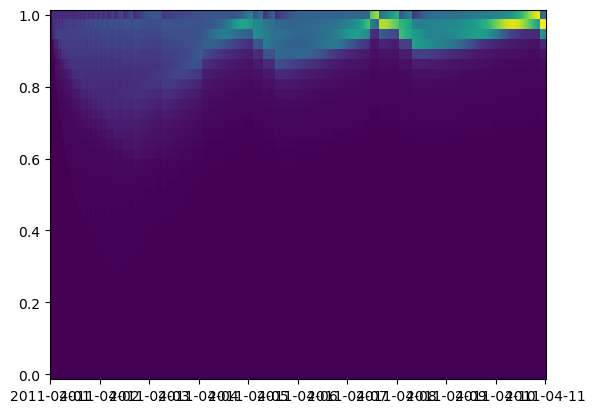

In [91]:
plt.pcolor(case_output.time.values, sigma_grid, np.where(np.isnan(result), 0, result))

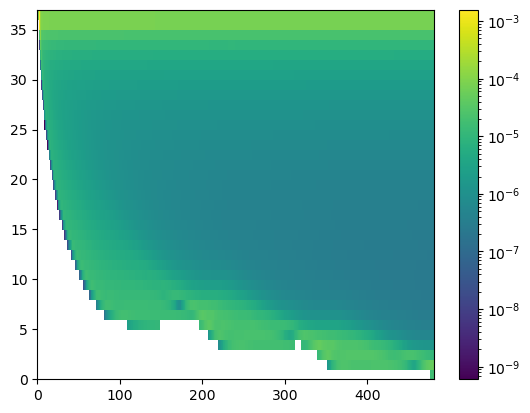

In [117]:
plt.pcolor(SS_cleaned, norm=colors.LogNorm())
plt.colorbar()

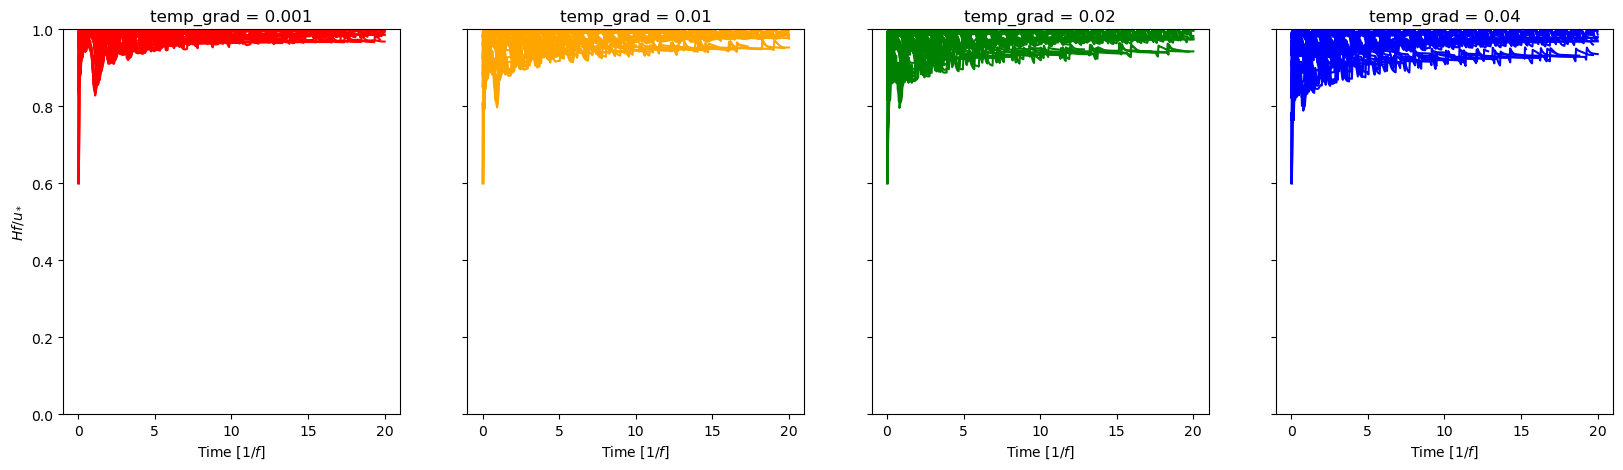

In [96]:
fig, ax = plt.subplots(1,4, figsize=(20,5), sharey=True)

for a in ax.flatten():
    a.set_ylim(0, 1)
    a.set_xlabel("Time [1/$f$]")

ax[0].set_ylabel("$Hf/u_*$")

for case, specs in gotm_case_dict.items():
    case_output = feature_retreiver.get_output(case)

    bl_tke = compute_tke_bl(case_output).values

    time_normed = np.arange(len(bl_tke)) * dt / calculate_T(specs['lat'])

    u_star = feature_retreiver.compute_u_star(case=case)
    f = feature_retreiver.compute_f(case=case)
    ekman_layer_thickness = compute_ekman_layer_thickness(nu=0.1, f=f)
    time_normed = np.arange(len(tke)) * dt / calculate_T(specs['lat'])
    if specs['temp_grad'] == 0.001:
        ax[0].plot(time_normed, -bl_dataset.bl.sel(case=case)/bl_tke, color="red")
        ax[0].set_title("temp_grad = 0.001")
    elif specs['temp_grad'] == 0.01:
        ax[1].plot(time_normed, -bl_dataset.bl.sel(case=case)/bl_tke, color="orange")
        ax[1].set_title("temp_grad = 0.01")
    elif specs['temp_grad'] == 0.02:
        ax[2].plot(time_normed, -bl_dataset.bl.sel(case=case)/bl_tke, color="green")
        ax[2].set_title("temp_grad = 0.02")
    elif specs['temp_grad'] == 0.04:
        ax[3].plot(time_normed, -bl_dataset.bl.sel(case=case)/bl_tke, color="blue")
        ax[3].set_title("temp_grad = 0.04")

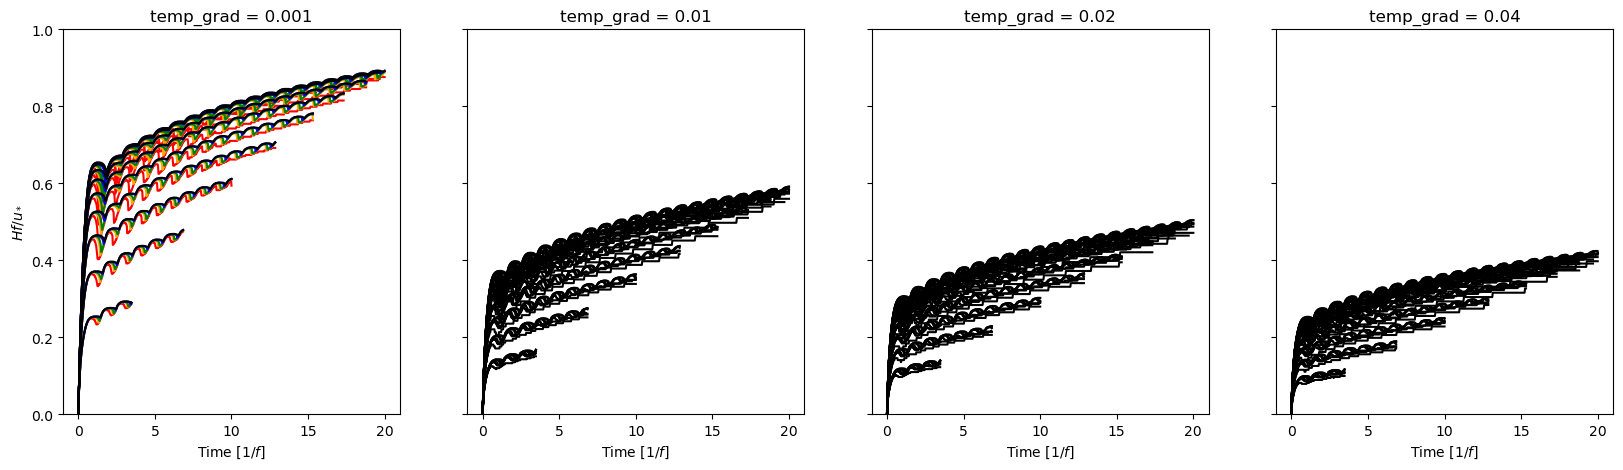

In [102]:
fig, ax = plt.subplots(1,4, figsize=(20,5), sharey=True)

for a in ax.flatten():
    a.set_ylim(0, 1)
    a.set_xlabel("Time [1/$f$]")

ax[0].set_ylabel("$Hf/u_*$")

for case, specs in gotm_case_dict.items():
    u_star = feature_retreiver.compute_u_star(case=case)
    f = feature_retreiver.compute_f(case=case)
    ekman_layer_thickness = compute_ekman_layer_thickness(nu=0.1, f=f)
    time_normed = np.arange(len(tke)) * dt / calculate_T(specs['lat'])
    if specs['temp_grad'] == 0.001:
        if specs['tx'] == 0.01:
            ax[0].plot(time_normed, bl_dataset.bl.sel(case=case)*f/u_star, color="red")
        elif specs['tx'] == 0.05:
            ax[0].plot(time_normed, bl_dataset.bl.sel(case=case)*f/u_star, color="orange")
        elif specs['tx'] == 0.1:
            ax[0].plot(time_normed, bl_dataset.bl.sel(case=case)*f/u_star, color="green")
        elif specs['tx'] == 0.5:
            ax[0].plot(time_normed, bl_dataset.bl.sel(case=case)*f/u_star, color="blue")
        elif specs['tx'] == 1.0:
            ax[0].plot(time_normed, bl_dataset.bl.sel(case=case)*f/u_star, color="black")
        ax[0].set_title("temp_grad = 0.001")
    elif specs['temp_grad'] == 0.01:
        ax[1].plot(time_normed, bl_dataset.bl.sel(case=case)*f/u_star, color="black")
        ax[1].set_title("temp_grad = 0.01")
    elif specs['temp_grad'] == 0.02:
        ax[2].plot(time_normed, bl_dataset.bl.sel(case=case)*f/u_star, color="black")
        ax[2].set_title("temp_grad = 0.02")
    elif specs['temp_grad'] == 0.04:
        ax[3].plot(time_normed, bl_dataset.bl.sel(case=case)*f/u_star, color="black")
        ax[3].set_title("temp_grad = 0.04")

    

    # plt.plot(time_normed, bl_dataset.bl.sel(case=case)*f/u_star, color="black")
    # plt.plot(bl_dataset.bl.sel(case=case)/ekman_layer_thickness)

In [105]:
calculate_T(10) / 24 / 60 / 60

np.float64(2.879385241571817)

In [99]:
ekman_depths = np.empty(len(gotm_case_dict))

for i, (case, specs) in enumerate(gotm_case_dict.items()):
    u_star = feature_retreiver.compute_u_star(case=case)
    f = feature_retreiver.compute_f(case=case)
    ekman_depths[i] = u_star / f

In [107]:
max(ekman_depths)/10000

np.float64(0.12355161500238541)

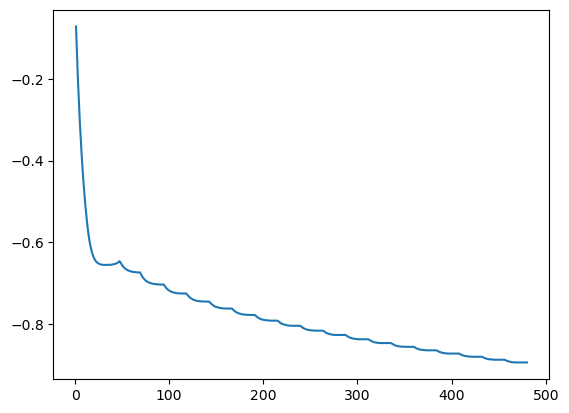

In [24]:
time_intervals = [1/4, 1/2, 3/4, 1, 3, 13/4, 7/2, 15/4, 4, 8, 33/4, 17/2, 35/4, 9]
# time_intervals = [1/4, 1/2, 3/4, 1, 5/4, 3/2, 7/4, 2]
time_stamps = get_time_stamps_for_profiles(dt, latitude, time_intervals)

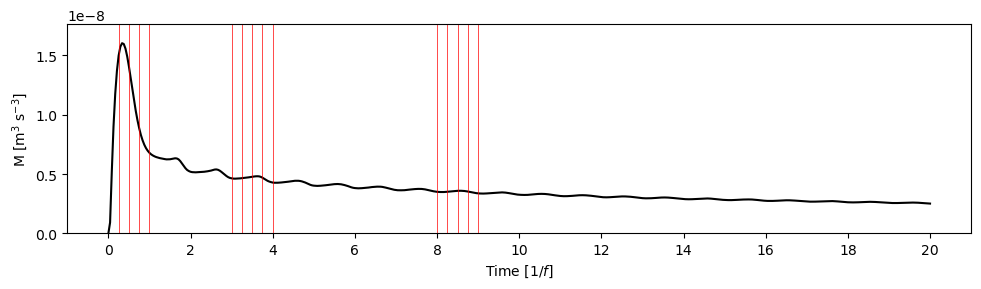

In [21]:
M = M_dataset.M.isel(case=case_ind).values
time_normed = np.arange(len(M)) * dt / calculate_T(latitude)
plt.figure(figsize=(10,3))
plt.ylabel(r"M [m$^3$ s$^{-3}$]")
plt.xlabel("Time [1/$f$]")
plt.gca().set_xticks(np.arange(0,22,2))
# plt.gca().set_xticks([0,1,2,3,4])
plt.plot(time_normed, M, color="black")
plt.ylim(np.min(M)-0.1*np.min(M), np.max(M)+0.1*np.max(M))
for time_stamp in time_stamps:
    plt.vlines(x=time_stamp * dt / calculate_T(latitude), ymin=0, ymax=1, colors="red", linewidth=0.5)

plt.tight_layout()

plt.savefig(f"figures/{case_name}_M_with_time_stamps.png", dpi=300)

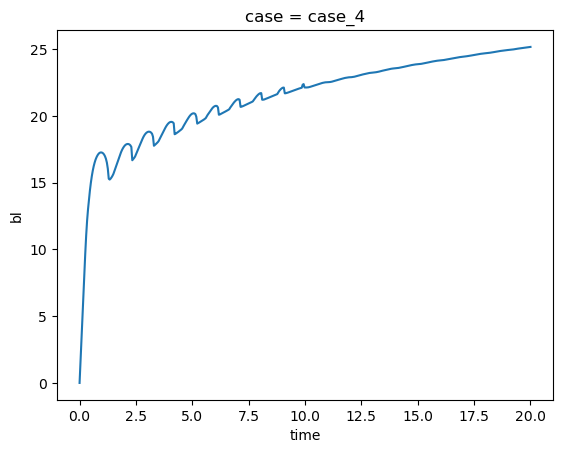

In [49]:
bl_dataset.bl.isel(case=case_ind).plot()

In [50]:
max_depth = 30

IndexError: index 518 is out of bounds for axis 0 with size 484

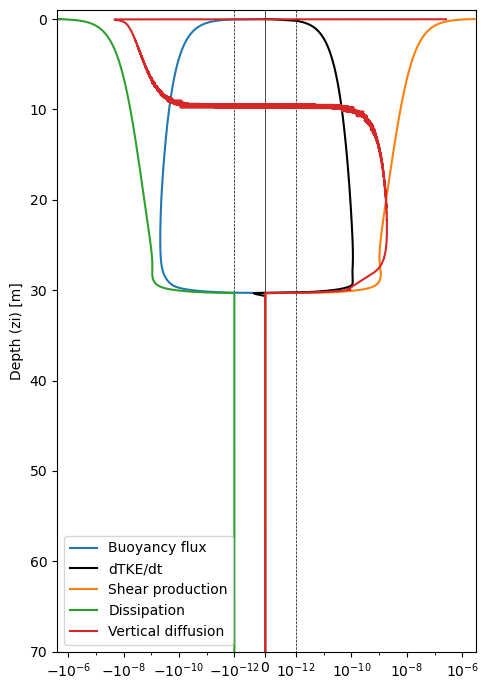

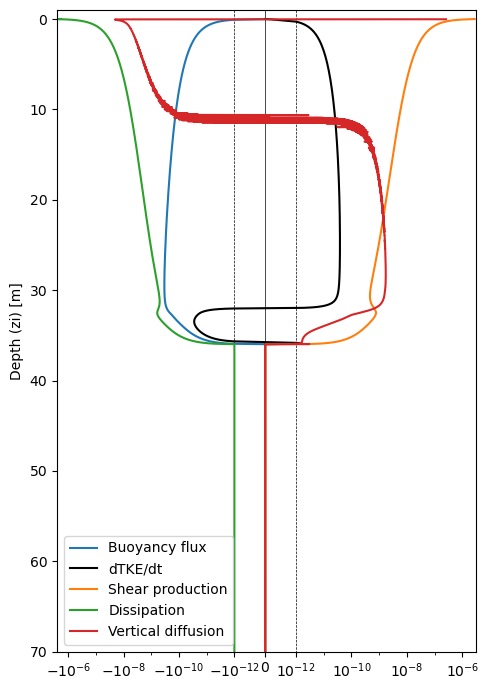

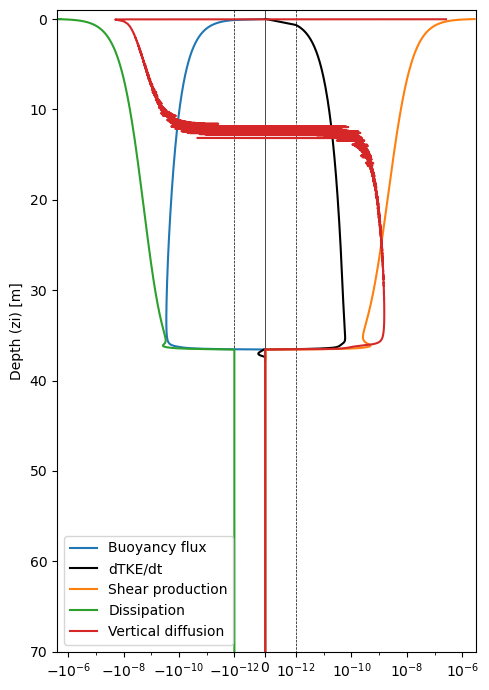

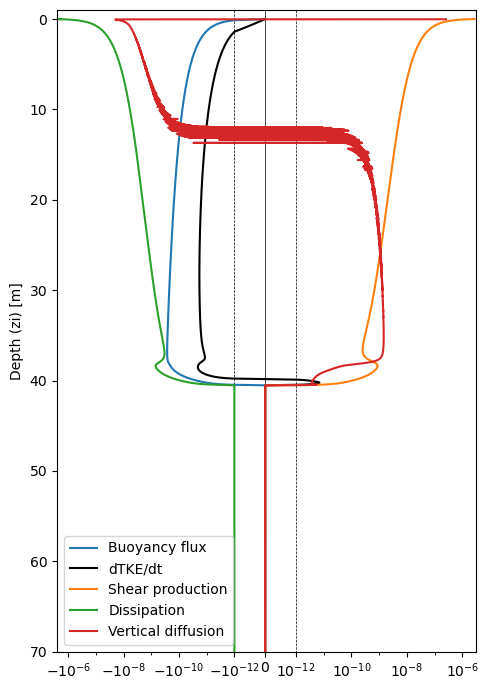

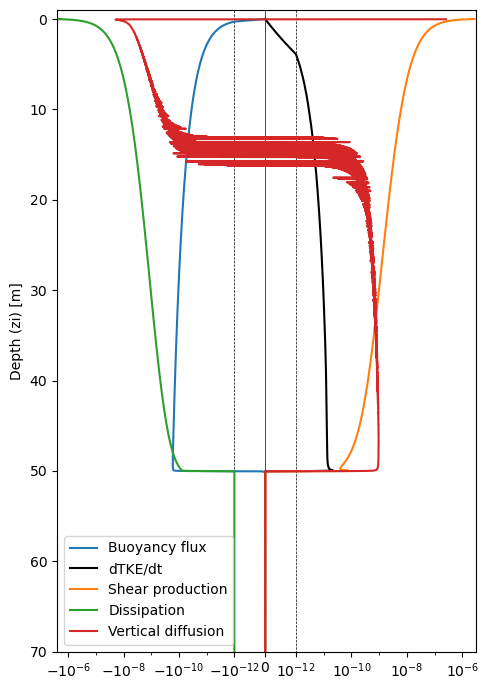

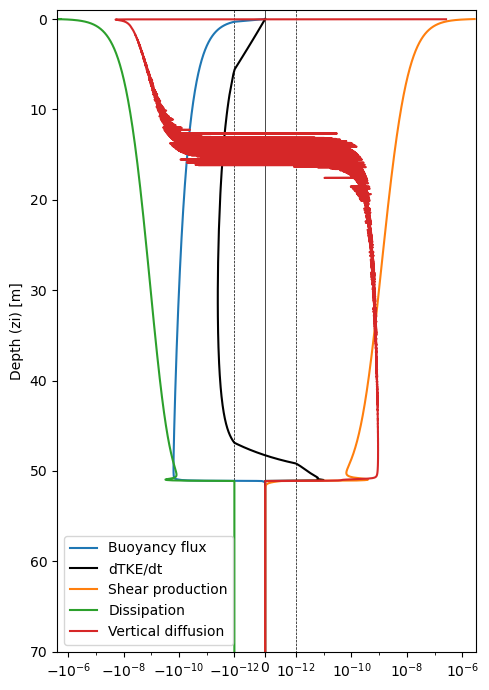

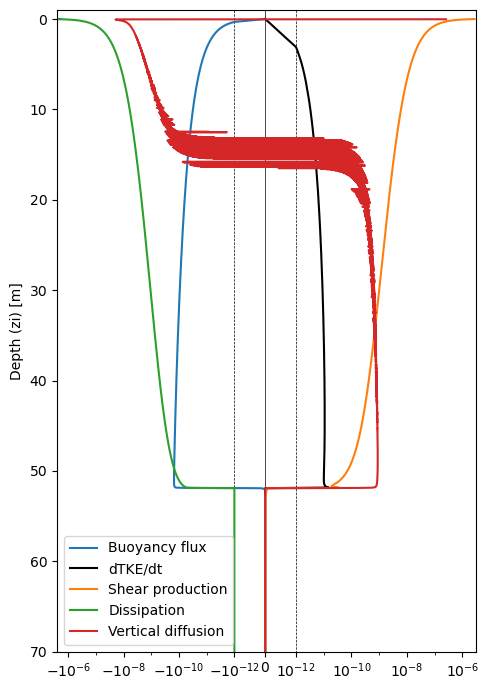

In [25]:
for time_stamp in time_stamps:
    G = case_output.isel(time=time_stamp).G.values
    P = case_output.isel(time=time_stamp).P.values
    D_1 = dnumdtke_dzi2[time_stamp-2]
    D_2 = dnumdtke_dzi2[time_stamp]
    D = (1-0.5) * D_1 + 0.5 * D_2
    eps = case_output.isel(time=time_stamp).eps.values
    zi = case_output.zi[0].values
    plt.figure(figsize=(5,7))
    plt.vlines(x=0, ymin=-1, ymax=max_depth, colors="black", linewidth=0.5)
    plt.vlines(x=1e-12, ymin=-1, ymax=max_depth, colors="black", linewidth=0.5, linestyle="dashed")
    plt.vlines(x=-1e-12, ymin=-1, ymax=max_depth, colors="black", linewidth=0.5, linestyle="dashed")
    plt.plot(G, -zi, label="Buoyancy flux")
    plt.plot(dtke_dt[time_stamp-2], -zi, label="dTKE/dt", color="black")
    # plt.plot(dtke_dt[time_stamp-2,2:-2]-G[2:-2]-P[2:-2]+eps[2:-2], -zi[2:-2], label="sum")
    plt.plot(P,-zi, label="Shear production")
    plt.ylabel("Depth (zi) [m]")
    plt.plot(-eps,-zi, label="Dissipation")
    plt.plot(D_2,-zi[2:-2], label="Vertical diffusion")
    plt.ylim(max_depth,-1)
    plt.gca().set_xscale("symlog", linthresh=1e-12)
    plt.gca().set_xticks([-1e-6, -1e-8, -1e-10, -1e-12, 0, 1e-12, 1e-10, 1e-8, 1e-6])
    plt.legend(loc=3)
    plt.tight_layout()

    # plt.savefig(f"figures/{case_name}_tke_budget_profile_time_stamp_{time_stamp}.png", dpi=300)

/tmp/ipykernel_3185951/300472378.py:6: RuntimeWarning: invalid value encountered in divide
  angle = np.arccos(u[:,-1]*tau/(np.sqrt(u[:,-1]**2+v[:,-1]**2)*tau))


IndexError: index 480 is out of bounds for axis 0 with size 480

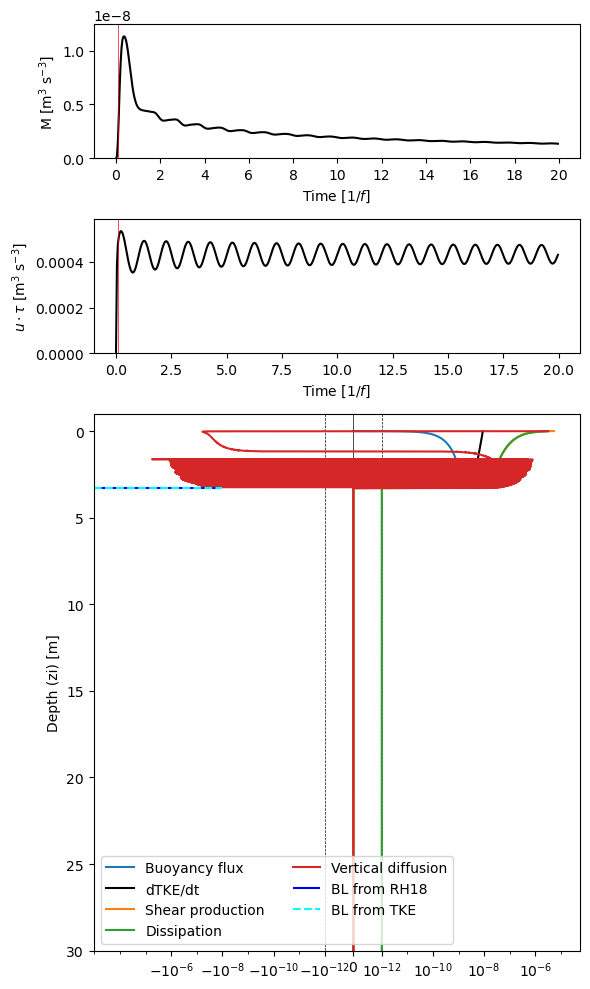

In [51]:
time_normed = np.arange(0,20*24) / 24
G = case_output.G.values[:len(time_normed)]
P = case_output.P.values[:len(time_normed)]
u, v = case_output.u.values[:len(time_normed)], case_output.v.values[:len(time_normed)]
u_dot_tau = u[:,-1]*tau
angle = np.arccos(u[:,-1]*tau/(np.sqrt(u[:,-1]**2+v[:,-1]**2)*tau))
eps = case_output.eps.values[:len(time_normed)]
zi = case_output.zi[0].values
z = case_output.z[0].values
M = M_dataset.M.isel(case=case_ind).values
Ekin = Ekin_dataset.Ekin.isel(case=case_ind).values
# time_normed = np.arange(len(M)) * dt / calculate_T(latitude)
time = case_output.time.values
time_steps = np.arange(2, len(time)-4)
grid = "f_u_star"

bl_1 = bl_dataset.bl.isel(case=case_ind).values
bl_2 = compute_tke_bl(case_output).values

fig, ax = plt.subplots(3,1, figsize=(6,10), gridspec_kw={"height_ratios": [1,1,4]})

def update(time_stamp):
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()

    ax[0].set_ylabel(r"M [m$^3$ s$^{-3}$]")
    ax[0].set_xlabel("Time [1/$f$]")
    ax[0].set_xticks(np.arange(0,22,2))
    ax[0].plot(time_normed, M, color="black")
    ax[0].set_ylim(np.min(M)*0.9, np.max(M)*1.1)
    # ax[0].vlines(x=time_stamp * dt / calculate_T(latitude), ymin=0, ymax=1, colors="red", linewidth=0.5)
    ax[0].vlines(x=time_normed[time_stamp], ymin=0, ymax=1, colors="red", linewidth=0.5)
    
    ax[1].plot(time_normed, u_dot_tau, color="black")
    ax[1].set_xlabel("Time [1/$f$]")
    ax[1].set_ylabel(r"$u \cdot \tau$ [m$^3$ s$^{-3}$]")
    ax[1].set_ylim(0,np.max(u_dot_tau)*1.1)
    # ax[1].vlines(x=time_stamp * dt / calculate_T(latitude), ymin=0, ymax=1, colors="red", linewidth=0.5)
    ax[1].vlines(x=time_normed[time_stamp], ymin=0, ymax=1, colors="red", linewidth=0.5)

    ax[-1].vlines(x=0, ymin=-1, ymax=max_depth, colors="black", linewidth=0.5)
    ax[-1].vlines(x=1e-12, ymin=-1, ymax=max_depth, colors="black", linewidth=0.5, linestyle="dashed")
    ax[-1].vlines(x=-1e-12, ymin=-1, ymax=max_depth, colors="black", linewidth=0.5, linestyle="dashed")
    ax[-1].plot(-G[time_stamp], -zi, label="Buoyancy flux")
    ax[-1].plot(dtke_dt[time_stamp-2], -zi, label="dTKE/dt", color="black")
    ax[-1].plot(P[time_stamp], -zi, label="Shear production")
    ax[-1].plot(eps[time_stamp], -zi, label="Dissipation")
    ax[-1].plot(dnumdtke_dzi2[time_stamp], -zi[2:-2], label="Vertical diffusion")
    ax[-1].hlines(y=bl_1[time_stamp], xmin=-1e-3, xmax=-1e-8, colors="blue", label="BL from RH18")
    ax[-1].hlines(y=-bl_2[time_stamp], xmin=-1e-3, xmax=-1e-8, colors="cyan", linestyle="dashed", label="BL from TKE")

    ax[-1].set_ylabel("Depth (zi) [m]")
    ax[-1].set_ylim(max_depth, -1)
    ax[-1].set_xscale("symlog", linthresh=1e-12)
    ax[-1].set_xticks([-1e-6, -1e-8, -1e-10, -1e-12, 0, 1e-12, 1e-10, 1e-8, 1e-6])
    ax[-1].legend(loc=3, ncol=2)
    fig.tight_layout()

ani = animation.FuncAnimation(fig, update, frames=time_steps, interval=200)
ani.save(f"figures/{case_name}_tke_budget_{grid}.gif", writer="pillow", dpi=150)

In [46]:
case_109_output = feature_retreiver.get_output("case_109")

In [51]:
case_output.rho_p

<xarray.DataArray 'rho_p' (time: 481, z: 4000)> Size: 8MB
[1924000 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 4kB 2011-04-01 ... 2011-04-11
    lon      float32 4B 0.0
    lat      float32 4B 10.0
    z        (time, z) float32 8MB -400.0 -399.9 -399.8 ... -0.25 -0.15 -0.05
Attributes:
    units:          kg/m3
    long_name:      density (potential)
    standard_name:  ??
    path:           /density
    cell_methods:   time: mean

/tmp/ipykernel_3926768/1829794257.py:5: RuntimeWarning: invalid value encountered in divide
  angle = np.arccos(u[:,-1]*tau/(np.sqrt(u[:,-1]**2+v[:,-1]**2)*tau))


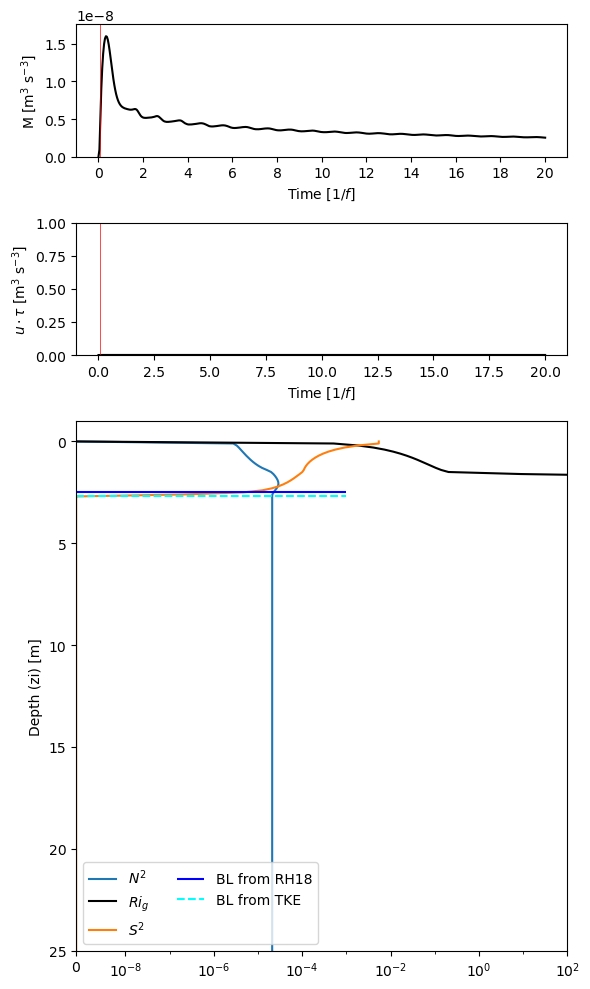

In [27]:
NN = case_output.NN.values
SS = case_output.SS.values
u, v = case_output.u.values, case_output.v.values
u_dot_tau = u[:,-1]*tau
angle = np.arccos(u[:,-1]*tau/(np.sqrt(u[:,-1]**2+v[:,-1]**2)*tau))
Rig = case_output.Rig.values
zi = case_output.zi[0].values
z = case_output.z[0].values
M = M_dataset.M.isel(case=case_ind).values
rho_p = case_output.rho_p.values
time_normed = np.arange(len(M)) * dt / calculate_T(latitude)
time = case_output.time.values
time_steps = np.arange(2, len(time)-4)

bl_1 = bl_dataset.bl.isel(case=case_ind).values
bl_2 = compute_tke_bl(case_output).values

fig, ax = plt.subplots(3,1, figsize=(6,10), gridspec_kw={"height_ratios": [1,1,4]})

def update(time_stamp):
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()

    ax[0].set_ylabel(r"M [m$^3$ s$^{-3}$]")
    ax[0].set_xlabel("Time [1/$f$]")
    ax[0].set_xticks(np.arange(0,22,2))
    ax[0].plot(time_normed, M, color="black")
    ax[0].set_ylim(np.min(M)-0.1*np.min(M), np.max(M)+0.1*np.max(M))
    ax[0].vlines(x=time_stamp * dt / calculate_T(latitude), ymin=0, ymax=1, colors="red", linewidth=0.5)
    
    ax[1].plot(time_normed, u_dot_tau, color="black")
    ax[1].set_xlabel("Time [1/$f$]")
    ax[1].set_ylabel(r"$u \cdot \tau$ [m$^3$ s$^{-3}$]")
    ax[1].set_ylim(0,1)
    ax[1].vlines(x=time_stamp * dt / calculate_T(latitude), ymin=0, ymax=1, colors="red", linewidth=0.5)

    ax[-1].vlines(x=0, ymin=-1, ymax=max_depth, colors="black", linewidth=0.5)
    ax[-1].vlines(x=1e-12, ymin=-1, ymax=max_depth, colors="black", linewidth=0.5, linestyle="dashed")
    ax[-1].vlines(x=-1e-12, ymin=-1, ymax=max_depth, colors="black", linewidth=0.5, linestyle="dashed")
    ax[-1].plot(NN[time_stamp], -zi, label="$N^2$")
    ax[-1].plot(Rig[time_stamp], -zi, label="$Ri_g$", color="black")
    ax[-1].plot(SS[time_stamp], -zi, label="$S^2$")
    # ax[-1].plot(rho_p[time_stamp], -z, label=r"$\rho$")
    # ax[-1].plot(u[time_stamp], -z, label="u")
    # ax[-1].plot(v[time_stamp], -z, label="v")
    ax[-1].hlines(y=bl_1[time_stamp], xmin=-1e-3, xmax=1e-3, colors="blue", label="BL from RH18")
    ax[-1].hlines(y=-bl_2[time_stamp], xmin=-1e-3, xmax=1e-3, colors="cyan", linestyle="dashed", label="BL from TKE")

    ax[-1].set_ylabel("Depth (zi) [m]")
    ax[-1].set_ylim(max_depth, -1)
    ax[-1].set_xlim([0, 1e2])
    ax[-1].set_xscale("symlog", linthresh=1e-8)
    ax[-1].set_xticks([0, 1e-8, 1e-6, 1e-4, 1e-2, 1e0, 1e2])
    ax[-1].legend(loc=3, ncol=2)
    fig.tight_layout()

ani = animation.FuncAnimation(fig, update, frames=time_steps, interval=200)
ani.save(f"figures/{case_name}_inputs.gif", writer="pillow", dpi=150)

/tmp/ipykernel_3926768/2389356537.py:8: RuntimeWarning: invalid value encountered in divide
  angle = np.arccos(u[:,-1]*tau/(np.sqrt(u[:,-1]**2+v[:,-1]**2)*tau))


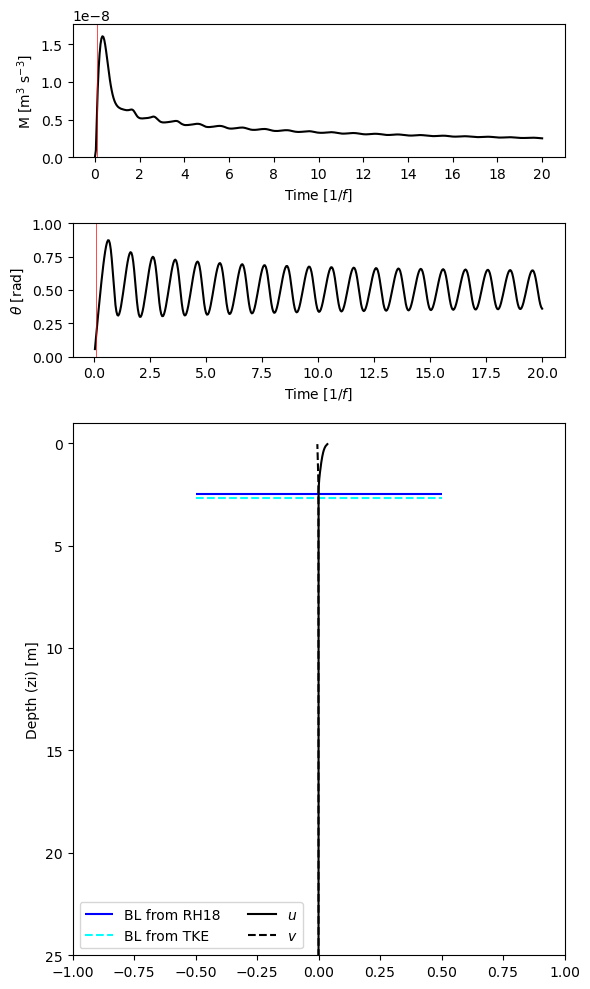

In [28]:
zi = case_output.zi[0].values
z = case_output.z[0].values
M = M_dataset.M.isel(case=case_ind).values
rho_p = case_output.rho_p.values
time_normed = np.arange(len(M)) * dt / calculate_T(latitude)
time = case_output.time.values
time_steps = np.arange(2, len(time)-4)
angle = np.arccos(u[:,-1]*tau/(np.sqrt(u[:,-1]**2+v[:,-1]**2)*tau))

bl_1 = bl_dataset.bl.isel(case=case_ind).values
bl_2 = compute_tke_bl(case_output).values

nu = 0.1
delta = compute_ekman_layer_thickness(nu=nu, f=calculate_f(latitude))
u_ekman, v_ekman = compute_ekman_spiral(
    tau=tau, 
    rho=feature_retreiver.rho0, 
    z=z, 
    delta=delta, 
    f=calculate_f(latitude), 
    nu=nu
)

u, v = case_output.u.values, case_output.v.values

Ekman = False
name = "velocities_ekman" if Ekman else "velocities"

fig, ax = plt.subplots(3,1, figsize=(6,10), gridspec_kw={"height_ratios": [1,1,4]})

def update(time_stamp):
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()

    ax[0].set_ylabel(r"M [m$^3$ s$^{-3}$]")
    ax[0].set_xlabel("Time [1/$f$]")
    ax[0].set_xticks(np.arange(0,22,2))
    ax[0].plot(time_normed, M, color="black")
    ax[0].set_ylim(np.min(M)-0.1*np.min(M), np.max(M)+0.1*np.max(M))
    ax[0].vlines(x=time_stamp * dt / calculate_T(latitude), ymin=0, ymax=1, colors="red", linewidth=0.5)
    
    ax[1].plot(time_normed, angle, color="black")
    ax[1].set_xlabel("Time [1/$f$]")
    ax[1].set_ylabel(r"$\theta$ [rad]")
    ax[1].set_ylim(0,1)
    ax[1].vlines(x=time_stamp * dt / calculate_T(latitude), ymin=0, ymax=1, colors="red", linewidth=0.5)

    ax[-1].hlines(y=bl_1[time_stamp], xmin=-0.5, xmax=0.5, colors="blue", label="BL from RH18")
    ax[-1].hlines(y=-bl_2[time_stamp], xmin=-0.5, xmax=0.5, colors="cyan", linestyle="dashed", label="BL from TKE")

    if Ekman:
        ax[-1].plot(u_ekman, -z, label="u$_{ekman}$", color="black")
        ax[-1].plot(-v_ekman, -z, label="v$_{ekman}$", color="black", linestyle="dashed")
        ax[-1].plot(u[time_stamp]-u_ekman, -z, label="$u_i$", color="red")
        ax[-1].plot(v[time_stamp]+v_ekman, -z, label="$v_i$", color="red", linestyle="dashed")
        xlim = [-0.5, 0.5]
        ncol = 3
        
    else:
        ax[-1].plot(u[time_stamp], -z, label="$u$", color="black")
        ax[-1].plot(v[time_stamp], -z, label="$v$", color="black", linestyle="dashed")
        ncol = 2
        xlim = [-1., 1.]
        
    ax[-1].set_ylabel("Depth (zi) [m]")
    ax[-1].set_ylim(max_depth, -1)
    ax[-1].set_xlim(xlim)
    ax[-1].legend(loc=3, ncol=ncol)
    
    fig.tight_layout()

ani = animation.FuncAnimation(fig, update, frames=time_steps, interval=200)
ani.save(f"figures/{case_name}_{name}.gif", writer="pillow", dpi=150)

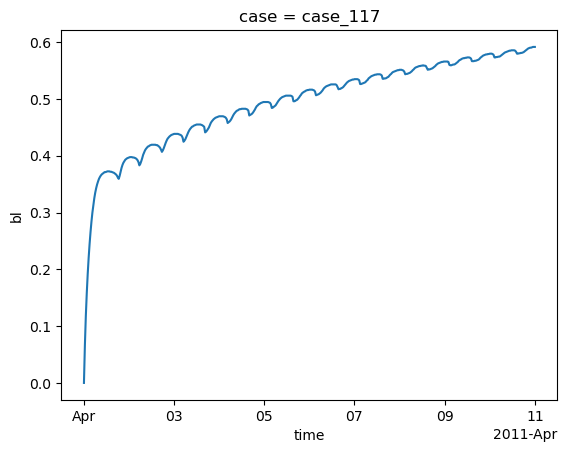

In [33]:
(bl_dataset.bl.isel(case=case_ind)/(u_star/f)).plot()

In [18]:
bl = compute_bl_rh18(output=case_27_output)

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:50: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)


In [47]:
bl_109 = compute_bl_rh18(output=case_109_output)

/gpfs/f5/gfdl_o/scratch/Marta.Mrozowska/hurricane_LES/make_smc_training_set/feature_retreiver.py:50: RuntimeWarning: All-NaN slice encountered
  bl = np.nanmax(bl_mask, axis=1)


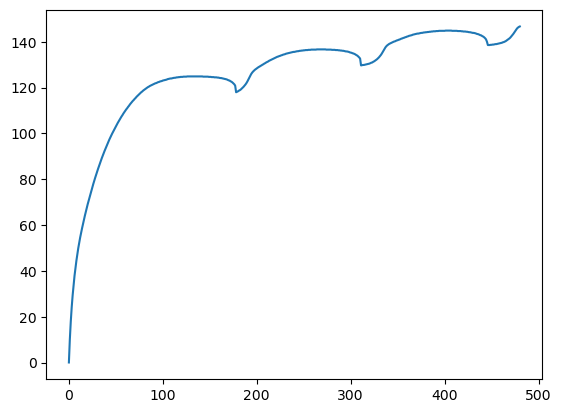

In [26]:
plt.plot(bl_109)

In [48]:
output = case_109_output

z_above = output.zi.where(output.tke > 1e-9).min(dim="zi")
z_below = output.zi.where(output.tke < 1e-9).max(dim="zi")

tke_above = output.tke.where(output.tke > 1e-9).min(dim="zi")
tke_below = output.tke.where(output.tke < 1e-9).max(dim="zi")

H = -1*(-z_above+z_below)/(tke_above-tke_below)*(1e-9-tke_below) + z_below

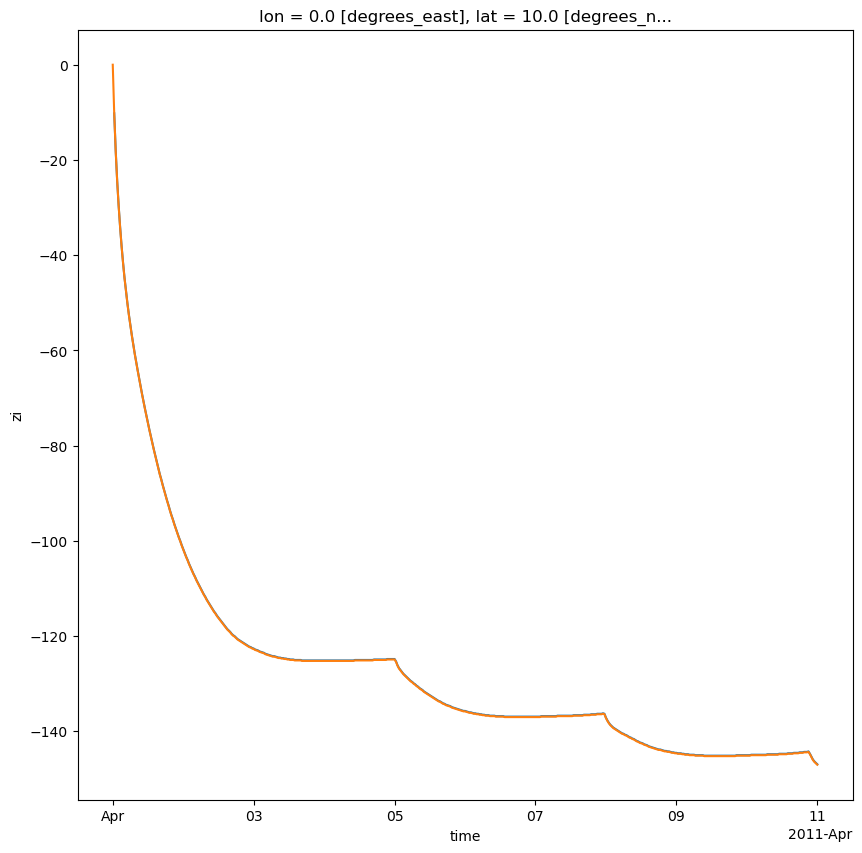

In [28]:
plt.figure(figsize=(10,10))

z_above.plot()
z_below.plot()

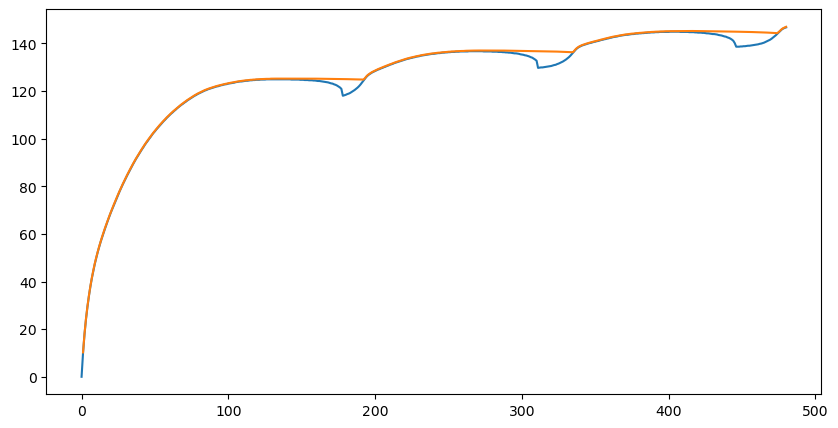

In [49]:
plt.figure(figsize=(10,5))

plt.plot(bl_109)
plt.plot(-H)

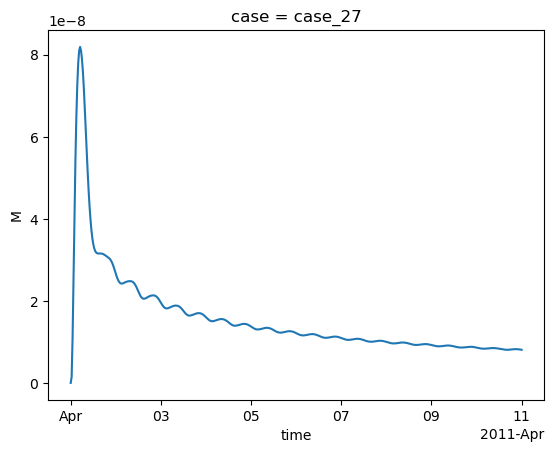

In [30]:
M_dataset.M.isel(case=0).plot()